In [1]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = LeftRightImagery(resample=None)
dataset= BNCI2014004()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


Not setting metadata
120 matching events found
No baseline correction applied
Not setting metadata
120 matching events found
No baseline correction applied
Not setting metadata
160 matching events found
No baseline correction applied
Not setting metadata
160 matching events found
No baseline correction applied
Not setting metadata
160 matching events found
No baseline correction applied
Not setting metadata
720 matching events found
No baseline correction applied


In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


No projector specified for this dataset. Please consider the method self.add_proj.


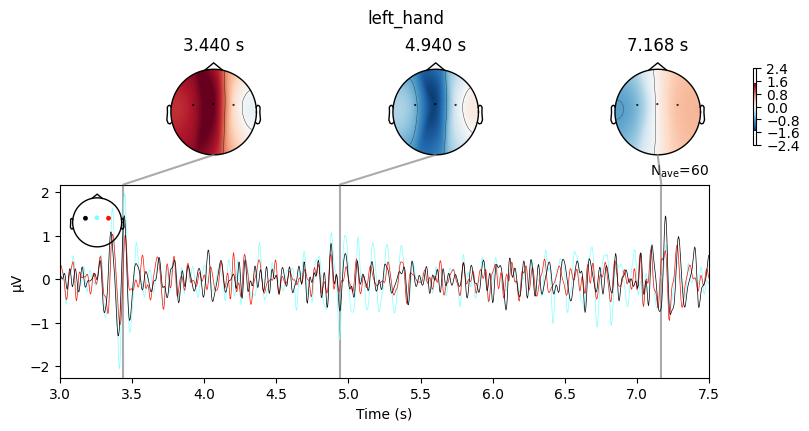

No projector specified for this dataset. Please consider the method self.add_proj.


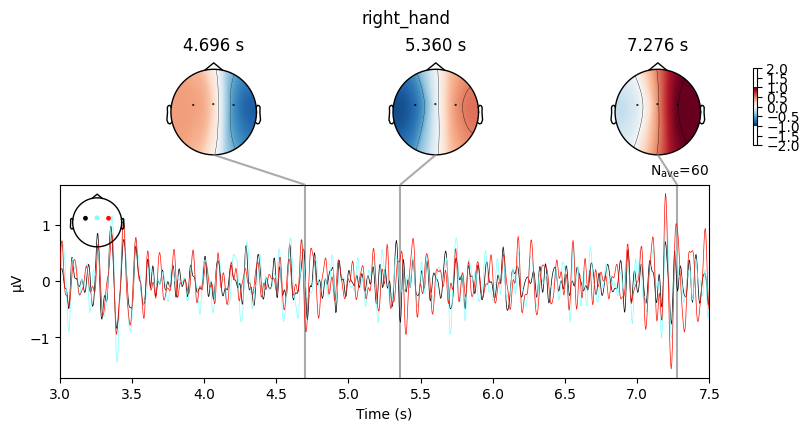

In [3]:
import numpy as np
ts_args=dict(ylim=dict(
    #eeg=[-15,15]
))
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [65]:
from hoda.tensorize import stf_tensor
from sklearn.preprocessing import StandardScaler
import tensorly as tl

X = epochs.get_data()
y = labels
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
X = tl.tensor(X)
X.shape

/tmp/ipykernel_1636/3963517579.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(120, 3, 16, 72)

<Axes: >

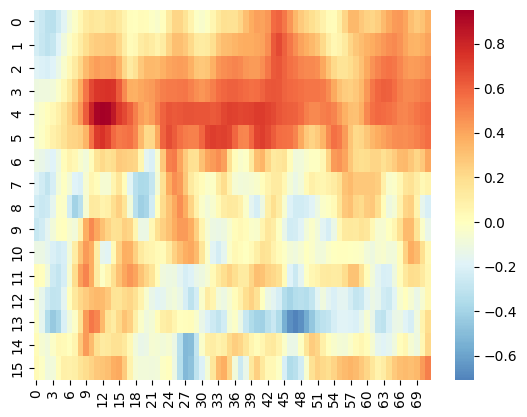

In [66]:
import seaborn as sns
contrast = tl.to_numpy(X[y=='right_hand'].mean(axis=0)) - tl.to_numpy(X[y=='left_hand'].mean(axis=0))
sns.heatmap(contrast[2], cmap="RdYlBu_r", center=0)

In [67]:
from hoda.hoda import HODA

hoda = HODA(
        rank=[3,8,8],
        max_iter=128,
        tol=1e-8,
        init ='eye',
        shrinkage='oas',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=True,
        verbose=True,
        random_state=42,
        delta=None,
        forward=True,
)


In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

Backward HODA model rank=(3, 8, 8):  13%|█▎        | 17/128 [00:14<01:32,  1.20it/s]


,iteration,mode,update,shrinkage,rank,objective,F_tr,F_rt,log_loss
0,1,0,1.192072e+00,0.087532,3,414720.000649,0.000066,0.013594,0.369936
1,1,1,1.518968e+00,0.098837,8,168606.046926,0.000150,0.022414,0.258220
2,1,2,1.428950e+00,0.212386,8,113529.210900,0.000287,0.079719,0.033595
3,2,0,1.327851e-15,0.176126,3,414720.000649,0.000287,0.079719,0.033595
4,2,1,1.044123e+00,0.098725,8,207956.793594,0.000509,0.081628,0.038961
5,2,2,1.324650e+00,0.171998,8,53859.880279,0.001275,0.053057,0.007707
6,3,0,2.134414e-15,0.112714,3,414720.000649,0.001275,0.053057,0.007707
7,3,1,9.699552e-01,0.068948,8,127819.588562,0.001913,0.049955,0.055055
8,3,2,1.337142e+00,0.168766,8,42879.184307,0.002374,0.029593,0.067864
9,4,0,3.584662e-15,0.120473,3,414720.000649,0.002374,0.029593,0.067864


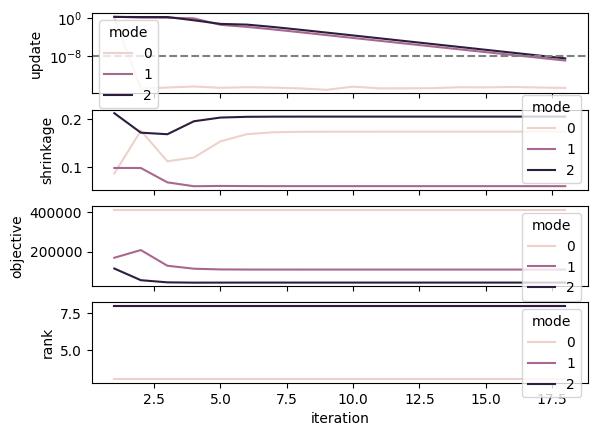

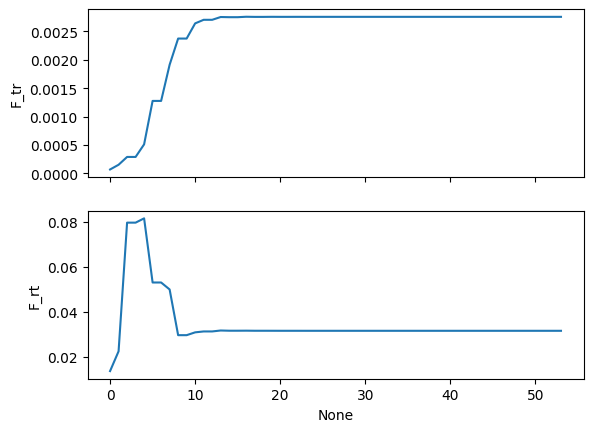

In [69]:
fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

In [70]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)



Forward model : 100%|██████████| 128/128 [00:02<00:00, 54.93it/s]


,iteration,mode,update,shrinkage,mse,nmse
0,0,0,inf,NaN,0.976174,0.976174
1,0,1,inf,NaN,0.976174,0.976174
2,0,2,inf,NaN,0.976174,0.976174
3,1,0,0.126988,0.178830,0.976360,0.976360
4,1,1,0.642618,0.024141,0.960419,0.960419
...,...,...,...,...,...,...
379,126,1,0.003217,0.024495,0.949825,0.949825
380,126,2,0.003093,0.018896,0.949830,0.949830
381,127,0,0.000134,0.144872,0.949830,0.949830
382,127,1,0.003217,0.024495,0.949825,0.949825


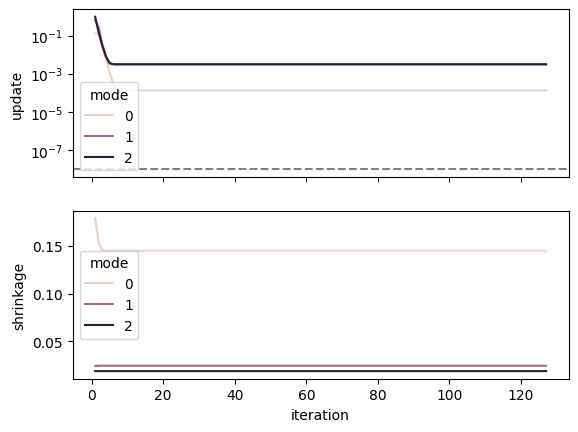

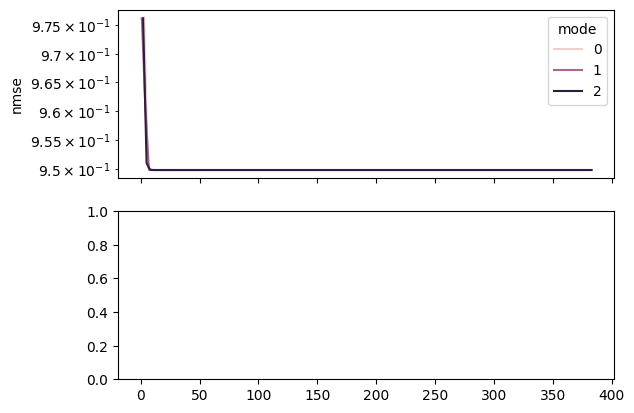

In [71]:

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='nmse', ax=axs[0], hue='mode')
    axs[0].set_yscale('log')


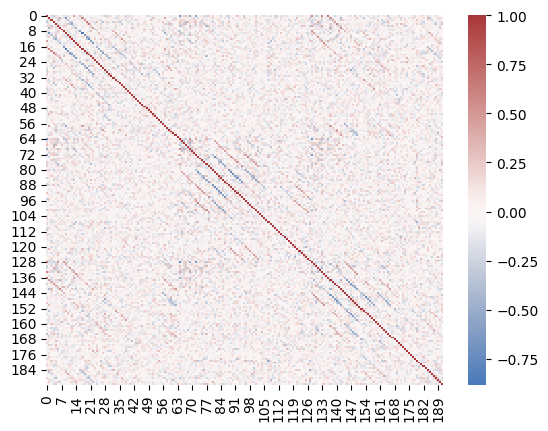

In [72]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
n_samples = len(X)
Xt = hoda.transform(X)

Xt_flat = tl.to_numpy(Xt.reshape(n_samples, -1))
if Xt_flat.shape[-1] > 1:
    sns.heatmap(np.corrcoef(Xt_flat, rowvar=False),  cmap='vlag', center=0)

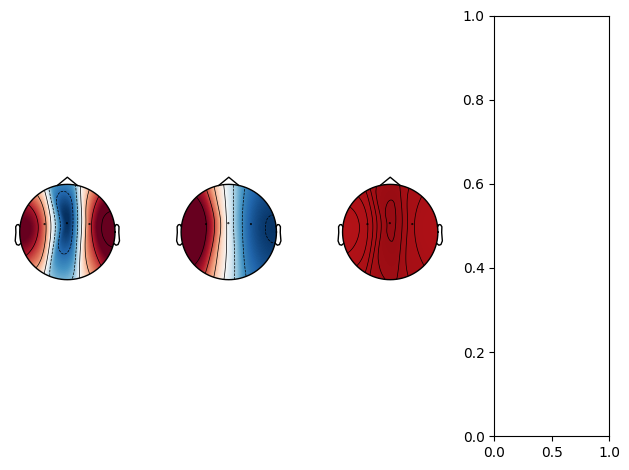

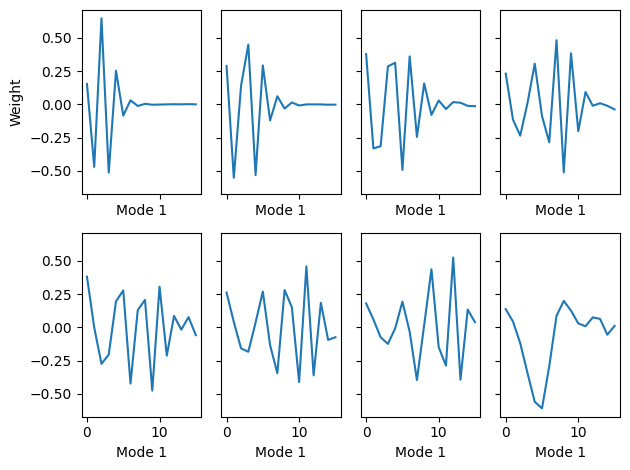

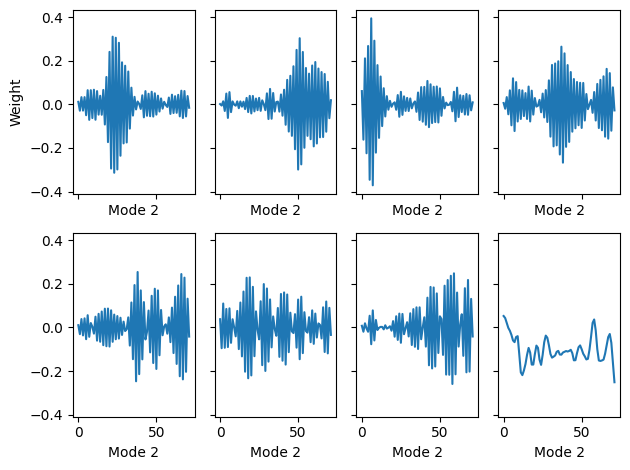

In [73]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');

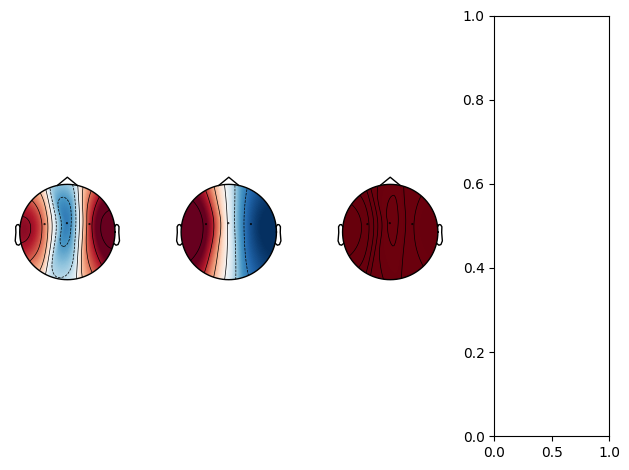

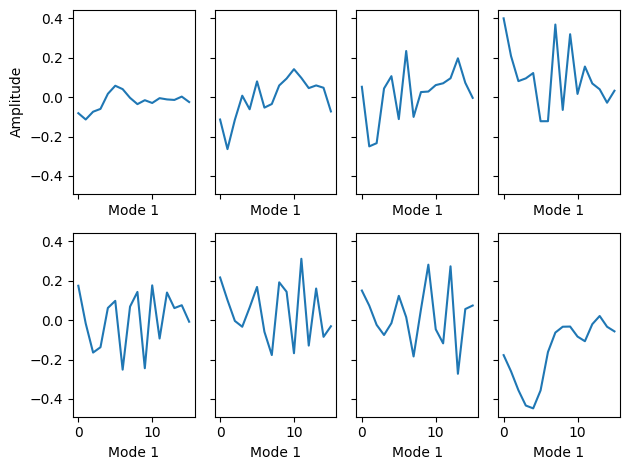

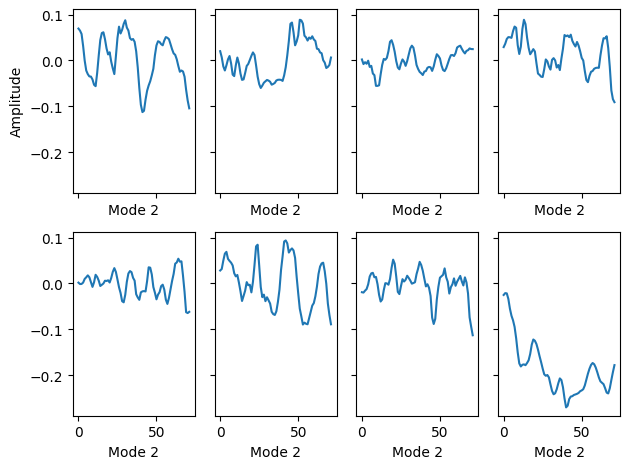

In [74]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

     index        PC1        PC2       label
0        0  10.550755  10.846663   left_hand
1        1   2.242968  -6.064611  right_hand
2        2   7.282648  -4.216453   left_hand
3        3   2.534945  -5.824058  right_hand
4        4   2.432488  -5.367244  right_hand
..     ...        ...        ...         ...
115    115   5.156035   8.856642   left_hand
116    116  -9.375358  -1.760869  right_hand
117    117   6.885798  14.734584   left_hand
118    118 -10.156947  -0.230014  right_hand
119    119  -7.503730   2.952649  right_hand

[120 rows x 4 columns]


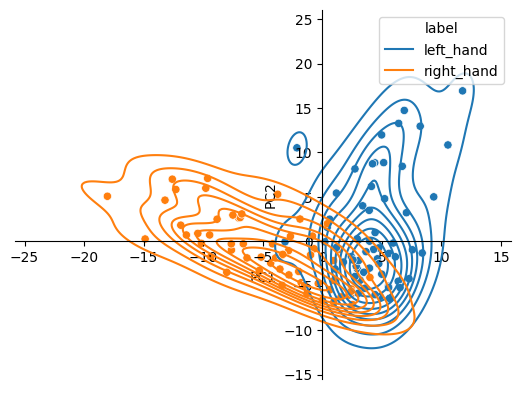

In [75]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=False)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
